In [1]:
# Loading data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_PATH = Path("..")
DATA_PATH = PROJECT_PATH / "data" / "raw"

customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")

In [49]:
import matplotlib.ticker as ticker

In [2]:
# convert dates
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [3]:
# merging orders with customers 
customer_orders = orders.merge(customers[ ["customer_id", "customer_unique_id", "customer_city", "customer_state"] ], on="customer_id", how="left" )
customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [6]:
# delivered orders
delivered_customer_orders = customer_orders[customer_orders["order_status"] == "delivered"].copy()
print("Delivered orders:", len(delivered_customer_orders))

Delivered orders: 96478


In [7]:
unique_customers = delivered_customer_orders["customer_unique_id"].nunique()
print(f"Unique customers: {unique_customers:,}")

Unique customers: 93,358


# Repeat Purchasing

In [8]:
# Repeat customers
customer_order_frequency = (delivered_customer_orders.groupby("customer_unique_id").agg(order_count=("order_id", "nunique")))

In [11]:
customer_order_frequency["customer_type"] = np.where(
    customer_order_frequency["order_count"] == 1,
    "One-time",
    "Repeat"
)

customer_order_frequency.head()

,order_count,customer_type
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,1,One-time
0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-time
0000f46a3911fa3c0805444483337064,1,One-time
0000f6ccb0745a6a4b88665a16c9f078,1,One-time
0004aac84e0df4da2b147fca70cf8255,1,One-time


In [12]:
customer_type_summary = (customer_order_frequency["customer_type"].value_counts().reset_index())
customer_type_summary.columns = ["customer_type", "customers"]
customer_type_summary["percentage"] = (customer_type_summary["customers"] / customer_type_summary["customers"].sum() * 100 )

customer_type_summary

,customer_type,customers,percentage
0,One-time,90557,96.999722
1,Repeat,2801,3.000278


In [13]:
repeat_customer_rate = ((customer_order_frequency["order_count"] > 1).mean() * 100)
print(f"Repeat customer rate: {repeat_customer_rate:.2f}%")

Repeat customer rate: 3.00%


In [14]:
# Purchase Frequency
purchase_frequency = (customer_order_frequency["order_count"].value_counts().sort_index() )
purchase_frequency

order_count
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

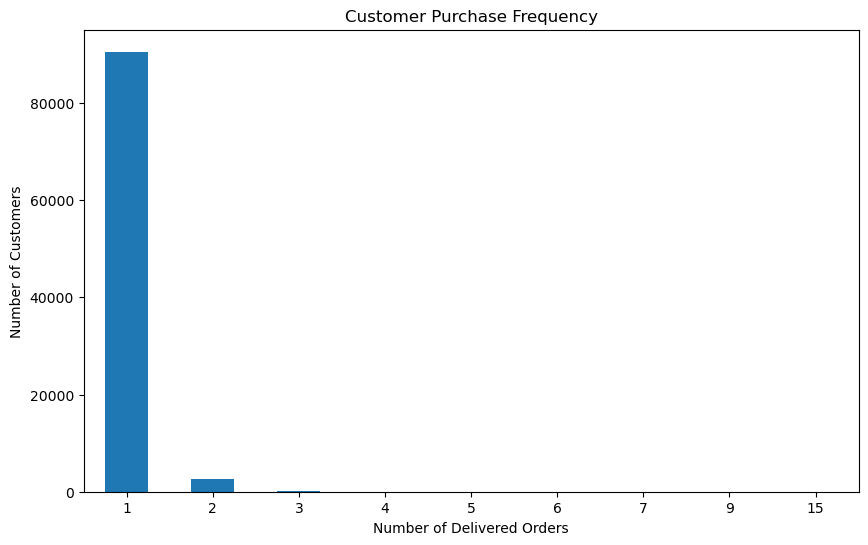

In [15]:
plt.figure(figsize=(10, 6))
purchase_frequency.plot(kind="bar")

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Delivered Orders")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

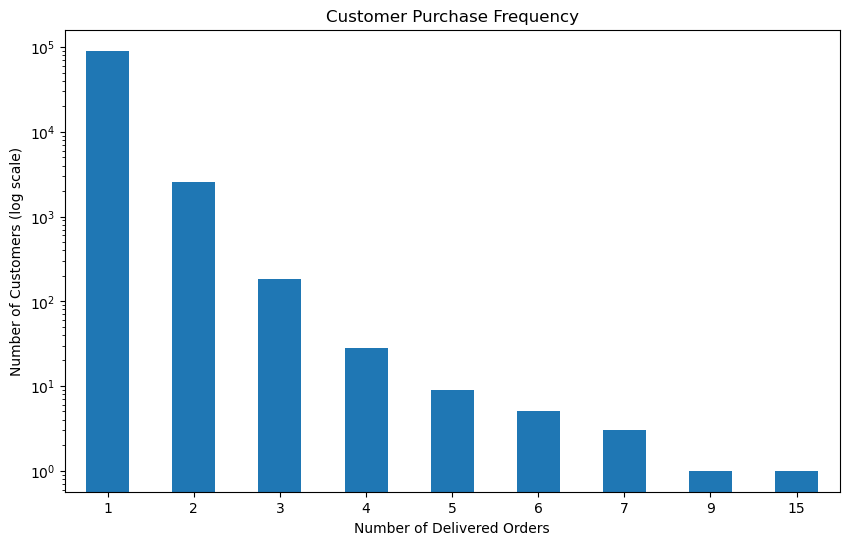

In [16]:
plt.figure(figsize=(10, 6))

purchase_frequency.plot(kind="bar")

plt.yscale("log")

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Delivered Orders")
plt.ylabel("Number of Customers (log scale)")
plt.xticks(rotation=0)

plt.show()

# Customer Value

In [17]:
# customer revenue
customer_sales = delivered_customer_orders[["order_id", "customer_unique_id"]].merge(
    order_items[ ["order_id", "product_id", "price", "freight_value"] ], on="order_id", how="inner" )

customer_sales.head()

,order_id,customer_unique_id,product_id,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,aa4383b373c6aca5d8797843e5594415,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72


In [18]:
customer_revenue = (customer_sales.groupby("customer_unique_id").agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum"),
        items_purchased=("product_id", "count"),
        orders=("order_id", "nunique")
    ).sort_values("revenue", ascending=False)
)

customer_revenue.head(15)

,revenue,freight,items_purchased,orders
customer_unique_id,,,,
0a0a92112bd4c708ca5fde585afaa872,13440.00,224.08,8,1
da122df9eeddfedc1dc1f5349a1a690c,7388.00,183.63,2,2
763c8b1c9c68a0229c42c9fc6f662b93,7160.00,114.88,4,1
dc4802a71eae9be1dd28f5d788ceb526,6735.00,194.31,1,1
459bef486812aa25204be022145caa62,6729.00,193.21,1,1
ff4159b92c40ebe40454e3e6a7c35ed6,6499.00,227.66,1,1
4007669dec559734d6f53e029e360987,5934.60,146.94,6,1
eebb5dda148d3893cdaf5b5ca3040ccb,4690.00,74.34,1,1
48e1ac109decbb87765a3eade6854098,4590.00,91.78,1,1


In [19]:
# Customer value distribution
customer_revenue["revenue"].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

count    93358.000000
mean       141.621480
std        215.694014
min          0.850000
25%         47.650000
50%         89.730000
75%        154.737500
90%        279.990000
95%        419.809000
99%       1004.990000
max      13440.000000
Name: revenue, dtype: float64

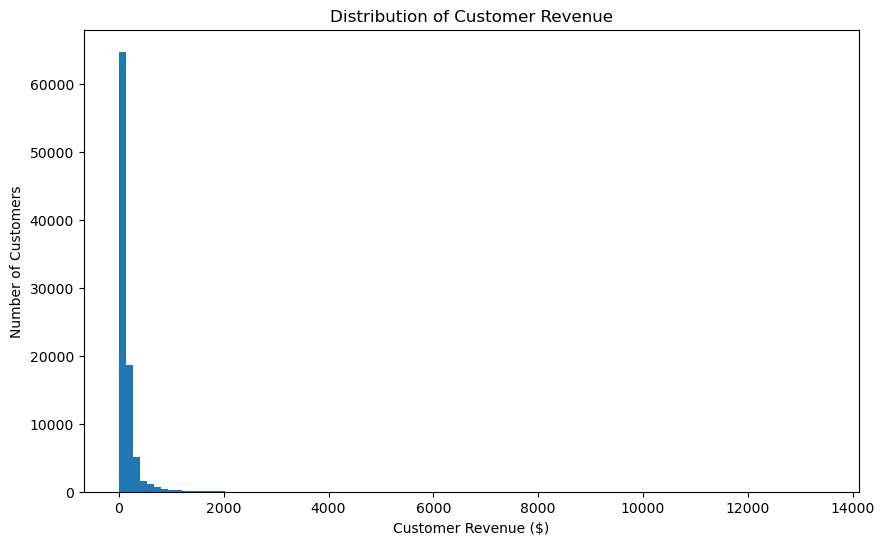

In [34]:
plt.figure(figsize=(10, 6))
plt.hist(customer_revenue["revenue"], bins=100 )

plt.title("Distribution of Customer Revenue")
plt.xlabel("Customer Revenue ($)")
plt.ylabel("Number of Customers")

plt.show()

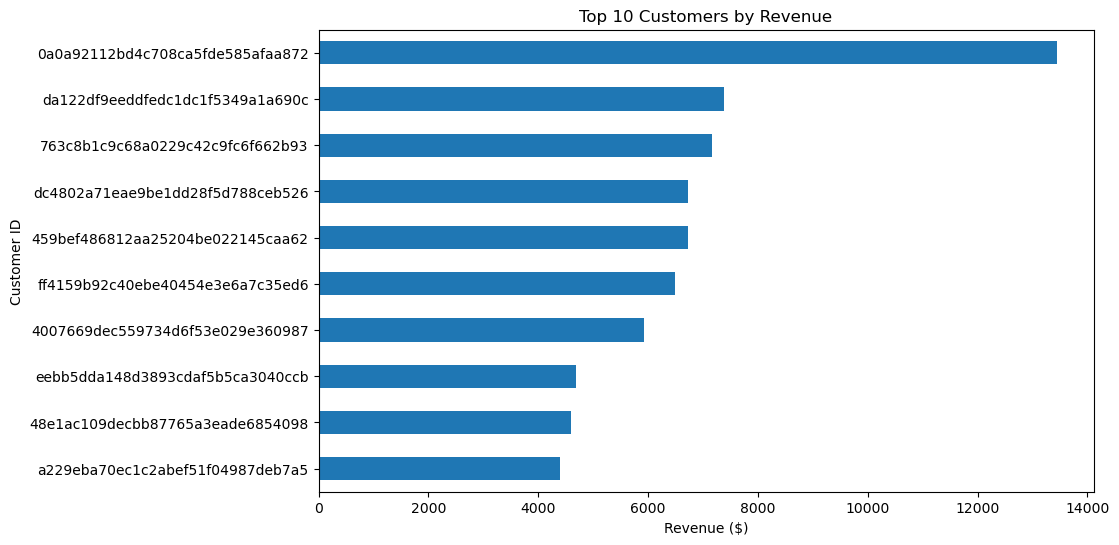

In [38]:
# top customers
top_10_customers = (customer_revenue.head(10).sort_values("revenue"))

plt.figure(figsize=(10, 6))

top_10_customers["revenue"].plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Customer ID")

plt.show()

In [40]:
# One-time vs repeat customer revenue
customer_analysis = customer_revenue.merge(customer_order_frequency[["customer_type"]], left_index=True, right_index=True, how="left" )
customer_analysis.head()

,revenue,freight,items_purchased,orders,customer_type
customer_unique_id,,,,,
0a0a92112bd4c708ca5fde585afaa872,13440.0,224.08,8,1,One-time
da122df9eeddfedc1dc1f5349a1a690c,7388.0,183.63,2,2,Repeat
763c8b1c9c68a0229c42c9fc6f662b93,7160.0,114.88,4,1,One-time
dc4802a71eae9be1dd28f5d788ceb526,6735.0,194.31,1,1,One-time
459bef486812aa25204be022145caa62,6729.0,193.21,1,1,One-time


In [41]:
customer_type_value = (customer_analysis.groupby("customer_type").agg(
        customers=("revenue", "count"),
        total_revenue=("revenue", "sum"),
        avg_revenue=("revenue", "mean"),
        median_revenue=("revenue", "median"),
        avg_orders=("orders", "mean")
    )
)

customer_type_value

,customers,total_revenue,avg_revenue,median_revenue,avg_orders
customer_type,,,,,
One-time,90557,12493089.36,137.958295,86.96,1.000000
Repeat,2801,728408.75,260.053106,182.10,2.113888


In [42]:
customer_type_value["revenue_share"] = (customer_type_value["total_revenue"] / customer_type_value["total_revenue"].sum() * 100 )
customer_type_value

,customers,total_revenue,avg_revenue,median_revenue,avg_orders,revenue_share
customer_type,,,,,,
One-time,90557,12493089.36,137.958295,86.96,1.000000,94.490725
Repeat,2801,728408.75,260.053106,182.10,2.113888,5.509275


In [43]:
# Customer AOV 
customer_analysis["customer_aov"] = (customer_analysis["revenue"] / customer_analysis["orders"] )
customer_analysis[ ["revenue", "orders", "customer_aov"] ].describe()

,revenue,orders,customer_aov
count,93358.000000,93358.000000,93358.000000
mean,141.621480,1.033420,137.508262
std,215.694014,0.209097,209.860279
min,0.850000,1.000000,0.850000
25%,47.650000,1.000000,46.000000
50%,89.730000,1.000000,86.990000
75%,154.737500,1.000000,149.900000
max,13440.000000,15.000000,13440.000000


In [44]:
# Customer Geography
customer_location = (delivered_customer_orders[ ["customer_unique_id", "customer_state"] ].drop_duplicates("customer_unique_id") )

customer_analysis = customer_analysis.merge(customer_location, on="customer_unique_id", how="left" )

In [46]:
# state-level customer performance
state_customer_analysis = (customer_analysis.groupby("customer_state").agg(
        customers=("customer_unique_id", "count"),
        revenue=("revenue", "sum"),
        avg_customer_revenue=("revenue", "mean")
    ).sort_values("revenue", ascending=False)
)

state_customer_analysis.head()

,customers,revenue,avg_customer_revenue
customer_state,,,
SP,39150,5068818.56,129.471738
RJ,11913,1759503.35,147.696076
MG,10996,1552492.70,141.187041
RS,5167,728977.47,141.083311
PR,4768,666158.31,139.714411


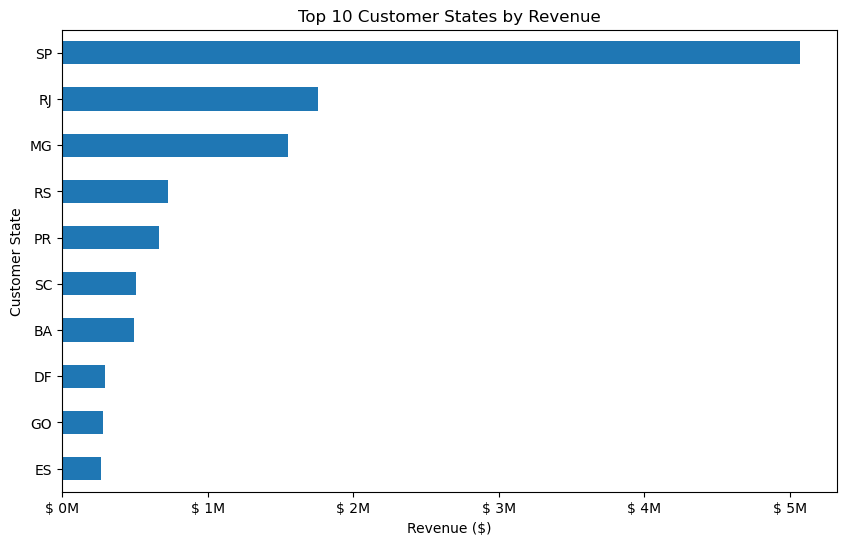

In [50]:
top_states = (state_customer_analysis.head(10).sort_values("revenue") )

plt.figure(figsize=(10, 6))

top_states["revenue"].plot(kind="barh")

plt.title("Top 10 Customer States by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Customer State")
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"$ {x/1_000_000:.0f}M"))

plt.show()

# RFM(Recency, Frequency, Monetary) Analysis

In [51]:
analysis_date = (delivered_customer_orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1) )
print("Analysis date:", analysis_date)

Analysis date: 2018-08-30 15:00:37


In [52]:
customer_purchase_dates = (delivered_customer_orders.groupby("customer_unique_id").agg(
        last_purchase=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique")
    )
)

customer_monetary = (customer_sales.groupby("customer_unique_id").agg(monetary=("price", "sum")))

rfm = customer_purchase_dates.merge(customer_monetary, left_index=True, right_index=True )

rfm["recency"] = (analysis_date - rfm["last_purchase"]).dt.days

rfm = rfm[ ["recency", "frequency", "monetary"] ]

rfm.head()

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
0000f46a3911fa3c0805444483337064,537,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
0004aac84e0df4da2b147fca70cf8255,288,1,180.00


In [53]:
# RFM scores
rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1] )

rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5] )

rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5] )

In [54]:
rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

In [55]:
rfm["RFM_score"] = ( rfm["R_score"] + rfm["F_score"] + rfm["M_score"] )
rfm.head()

,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,9
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,6
0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,4
0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,4
0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,8


# Customer Segments

In [56]:
def rfm_segment(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champions"
    elif row["R_score"] >= 4 and row["F_score"] >= 3:
        return "Loyal Customers"
    elif row["R_score"] >= 4 and row["M_score"] >= 4:
        return "High Value New"
    elif row["R_score"] <= 2 and row["F_score"] >= 4:
        return "At Risk Loyal"
    elif row["R_score"] <= 2 and row["M_score"] >= 4:
        return "At Risk High Value"    
    elif row["R_score"] >= 3 and row["F_score"] <= 2:
        return "New / Promising"    
    else:
        return "Other"

rfm["segment"] = rfm.apply(rfm_segment, axis=1)

In [57]:
rfm["segment"].value_counts()

segment
Other                 25284
New / Promising       16375
Loyal Customers       15932
At Risk Loyal         14803
At Risk High Value     8465
Champions              6517
High Value New         5982
Name: count, dtype: int64

In [59]:
# segment performance
segment_summary = ( rfm.groupby("segment").agg(
        customers=("monetary", "count"),
        revenue=("monetary", "sum"),
        avg_revenue=("monetary", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_recency=("recency", "mean")
    ).sort_values("revenue", ascending=False)
)

segment_summary

,customers,revenue,avg_revenue,avg_frequency,avg_recency
segment,,,,,
At Risk High Value,8465,2364579.16,279.335991,1.000000,393.862847
Other,25284,2310909.37,91.398092,1.026024,317.164847
At Risk Loyal,14803,2158022.69,145.782793,1.072080,394.933932
Champions,6517,1785868.12,274.032242,1.171091,91.462176
High Value New,5982,1582172.33,264.488855,1.000000,91.719659
Loyal Customers,15932,1536320.83,96.429879,1.017575,89.925559
New / Promising,16375,1483625.61,90.603091,1.000000,148.818076


In [60]:
# revenue share
segment_summary["revenue_share"] = (segment_summary["revenue"] / segment_summary["revenue"].sum() * 100 )
segment_summary

,customers,revenue,avg_revenue,avg_frequency,avg_recency,revenue_share
segment,,,,,,
At Risk High Value,8465,2364579.16,279.335991,1.000000,393.862847,17.884351
Other,25284,2310909.37,91.398092,1.026024,317.164847,17.478423
At Risk Loyal,14803,2158022.69,145.782793,1.072080,394.933932,16.322074
Champions,6517,1785868.12,274.032242,1.171091,91.462176,13.507305
High Value New,5982,1582172.33,264.488855,1.000000,91.719659,11.966665
Loyal Customers,15932,1536320.83,96.429879,1.017575,89.925559,11.619870
New / Promising,16375,1483625.61,90.603091,1.000000,148.818076,11.221312


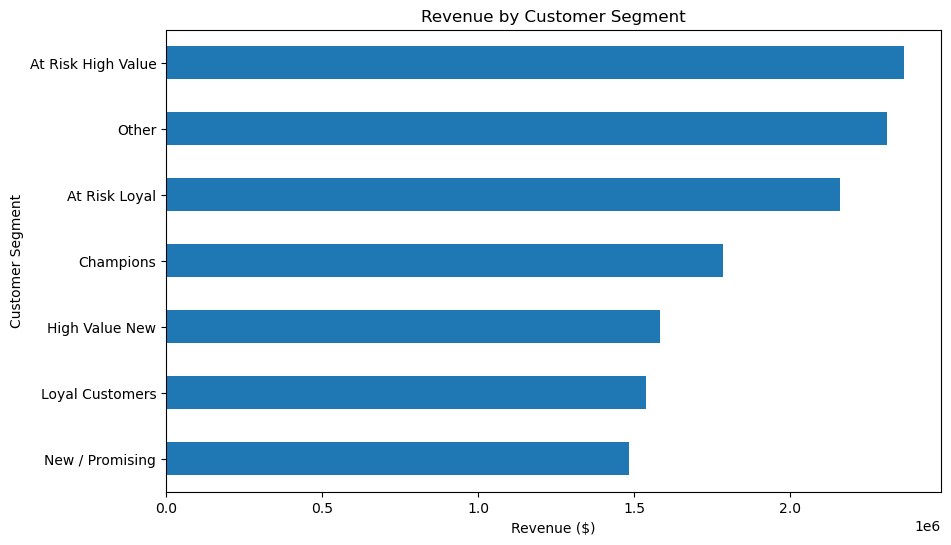

In [61]:
segment_revenue = ( segment_summary["revenue"].sort_values() )

plt.figure(figsize=(10, 6))

segment_revenue.plot(kind="barh")

plt.title("Revenue by Customer Segment")
plt.xlabel("Revenue ($)")
plt.ylabel("Customer Segment")

plt.show()

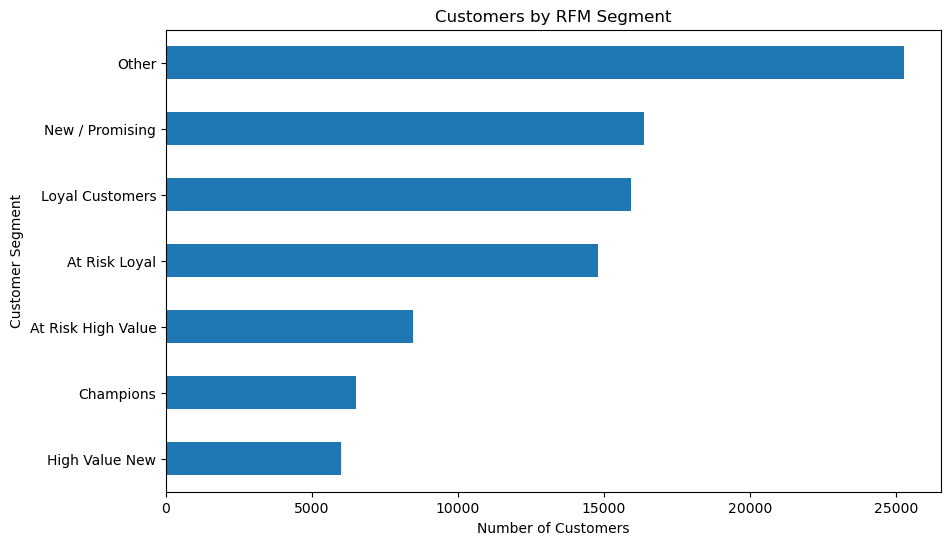

In [62]:
segment_customers = (segment_summary["customers"].sort_values() )

plt.figure(figsize=(10, 6))

segment_customers.plot(kind="barh")

plt.title("Customers by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.show()

In [75]:
# saving outputs

In [77]:
PROCESSED_PATH = PROJECT_PATH / "data" / "processed"

In [78]:
rfm.reset_index().to_csv( PROCESSED_PATH / "customer_rfm.csv", index=False )

In [79]:
segment_summary.reset_index().to_csv(PROCESSED_PATH / "customer_segments.csv",index=False)

In [80]:
customer_analysis.reset_index().to_csv(PROCESSED_PATH / "customer_analysis.csv",index=False)